# Actionability Audit


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Consistent language palette (use in all plots)
# Add more languages here if they appear in your data.
LANG_ORDER = ["en", "es", "pt"]
LANG_PALETTE = {
    "en": "#295574",  # blue
    "es": "#e75e1e",  # orange
    "pt": "#2ca062",  # green
}

def lang_color(lang: str) -> str:
    """Return a stable color for a language code (fallback to gray)."""
    key = ("" if lang is None else str(lang)).strip().lower()
    return LANG_PALETTE.get(key, "#7f7f7f")

In [56]:
df_out = pd.read_csv("../output/sentences_actionability.csv")
#show just sentence column and actionability_probability
pd.set_option("display.max_colwidth", None)   # show full text in cells
pd.set_option("display.max_rows", 60)         # optional
pd.set_option("display.width", 0)             # auto-detect width
df_out[["sentence", "actionability_probability"]].sort_values("actionability_probability", ascending=False).head()

,sentence,actionability_probability
1326,"Toda la CDMX en alerta por lluviasAdemás de las tres alcaldías de la Ciudad de México con alerta roja, hay recomendaciones en las otras 13 demarcaciones por la posible caída de granizo y lluvias fuertes.",1.0000
2407,"O alerta vale até as 10h de segunda-feira (17), e as autoridades locais recomendam que os moradores se mantenham atentos às condições climáticas e sigam as orientações de segurança.",1.0000
742,"CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça-feira (30/4), para auxiliar no resgate dos atingidos pelas enchentes na região de Santa Maria, no Rio Grande do Sul.",0.9804
1863,"Personal de la Municipalidad a la par de la entrega de los sacos, recomienda a los pobladores cuyas viviendas se ubican en zonas de desnivel con relación a la pista que protejan sus casas, llenando con tierra o arena los sacos que se les proporciona y no esperar que se presenten las lluvias para recién hacerlo.",0.9804
293,"Denúncias- Em caso de incêndio em mata ou floresta, a Defesa Civil orienta que a população avise imediatamente o Corpo de Bombeiros (193), Defesa Civil (199) ou Polícia Militar (190)Recomendações- Outra orientação, é para que moradores das regiões de risco se inscrevam nos serviços de alerta, enviando um SMS, com o CEP do local onde mora, para o número 40199.",0.9804


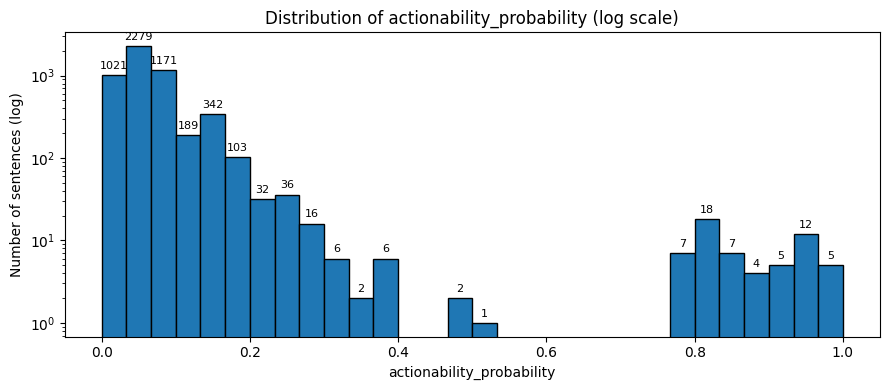

In [57]:

# log-scaled histogram of actionability_probability with counts on top of bars

col = "actionability_probability"
if col not in df_out.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df_out.columns)}")

s = pd.to_numeric(df_out[col], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(9, 4))

counts, bins, patches = ax.hist(s, bins=30, edgecolor="black")

ax.set_yscale("log")
ax.set_title("Distribution of actionability_probability (log scale)")
ax.set_xlabel("actionability_probability")
ax.set_ylabel("Number of sentences (log)")

# label each bar with its count (skip zeros)
for c, p in zip(counts, patches):
    if c <= 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f"{int(c)}",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()



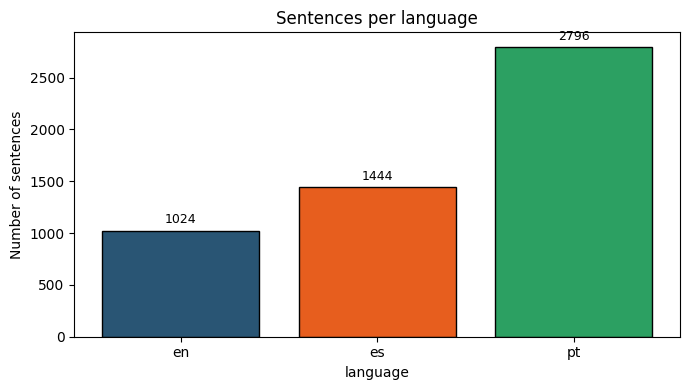

In [58]:

# bar chart: number of sentences per language (linear scale) with counts on top

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

# Keep a stable order + colors across the notebook
counts_by_lang = dfp[lang_col].value_counts()
counts_by_lang = counts_by_lang.reindex(LANG_ORDER, fill_value=0)
colors = [lang_color(l) for l in counts_by_lang.index.tolist()]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    counts_by_lang.index.tolist(),
    counts_by_lang.values.tolist(),
    edgecolor="black",
    color=colors,
 )

ax.set_title("Sentences per language")
ax.set_xlabel("language")
ax.set_ylabel("Number of sentences")

# labels on top of bars
for b in bars:
    h = b.get_height()
    if h <= 0:
        continue
    ax.annotate(
        f"{int(h)}",
        (b.get_x() + b.get_width() / 2, h),
        ha="center",
        va="bottom",
        fontsize=9,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()

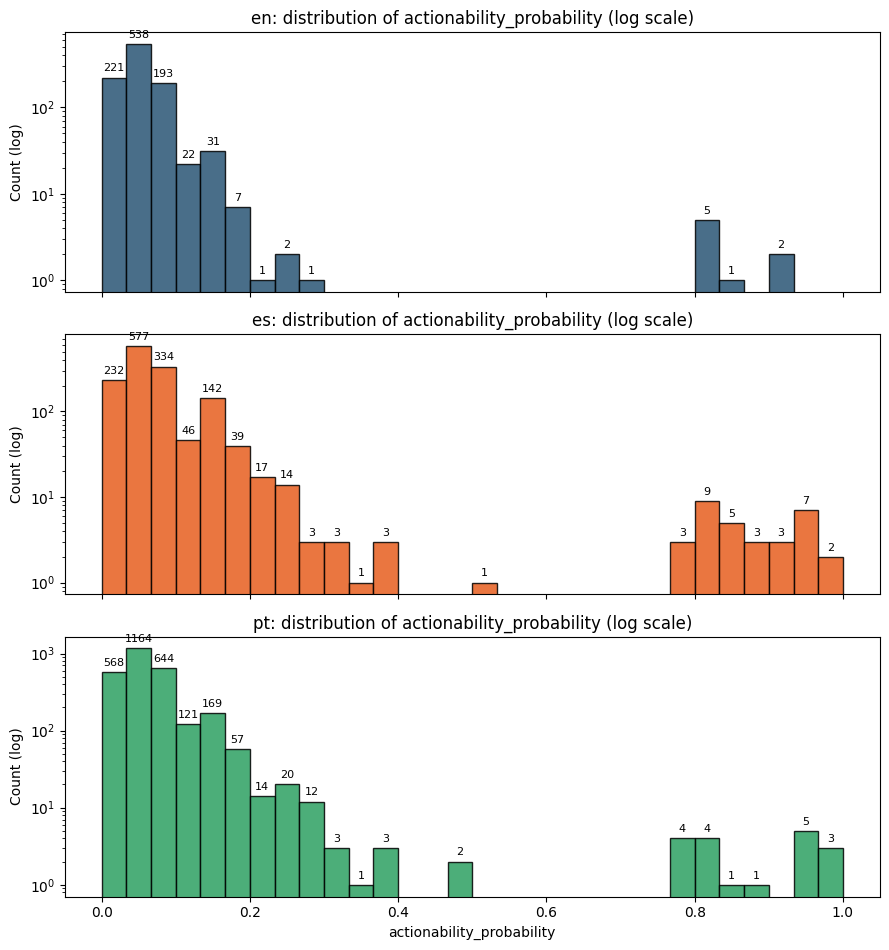

In [59]:
# subplots: one histogram per language for actionability_probability (log y) with counts on bars

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

langs_found = sorted(dfp[lang_col].unique().tolist())
if not langs_found:
    raise ValueError("No languages found.")

# Stable subplot ordering: LANG_ORDER first, then any extras
langs = [l for l in LANG_ORDER if l in langs_found] + [l for l in langs_found if l not in LANG_ORDER]

# Use shared bins across languages so plots are comparable
xmin = float(dfp[col].min())
xmax = float(dfp[col].max())
if xmin == xmax:
    # degenerate case: all probs equal
    bins = np.linspace(max(0.0, xmin - 1e-6), min(1.0, xmax + 1e-6), 2)
else:
    bins = np.linspace(xmin, xmax, 31)  # 30 bins

fig, axes = plt.subplots(nrows=len(langs), ncols=1, figsize=(9, 3.2 * len(langs)), sharex=True)
if len(langs) == 1:
    axes = [axes]

for ax, lang in zip(axes, langs):
    s = dfp.loc[dfp[lang_col] == lang, col]
    color = lang_color(lang)

    counts, _, patches = ax.hist(
        s,
        bins=bins,
        edgecolor="black",
        color=color,
        alpha=0.85,
    )
    ax.set_yscale("log")
    ax.set_title(f"{lang}: distribution of {col} (log scale)")
    ax.set_ylabel("Count (log)")

    # label counts on bars
    for c, p in zip(counts, patches):
        if c <= 0:
            continue
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(
            f"{int(c)}",
            (x, y),
            ha="center",
            va="bottom",
            fontsize=8,
            textcoords="offset points",
            xytext=(0, 3),
        )

axes[-1].set_xlabel(col)

plt.tight_layout()
plt.show()

### Bias in language model predictions


In [60]:
# ------------------------------------------------------------
# Statistical similarity of actionability_probability by language
#   - KS test (sensitive to any distribution difference)
#   - Wasserstein distance (earth mover; interpretable in prob units)
#   - Jensen–Shannon distance (symmetric; bounded; info-theoretic)
#   - Optional bootstrap CIs for the distances
#
# NOTE on JSD CIs: we use ONE shared histogram binning for ALL pairs and
# for the bootstrap as well. Additionally, we compute the reported point JSD
# using the same histogram pipeline as the bootstrap, so point+CI are consistent.
# ------------------------------------------------------------

from itertools import combinations

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

langs_found = sorted(dfp[lang_col].unique().tolist())
langs = [l for l in LANG_ORDER if l in langs_found] + [l for l in langs_found if l not in LANG_ORDER]
if len(langs) < 2:
    raise ValueError(f"Need at least 2 languages to compare. Found: {langs}")

try:
    from scipy.stats import ks_2samp, wasserstein_distance
    from scipy.spatial.distance import jensenshannon
    _HAVE_SCIPY = True
except Exception as e:
    _HAVE_SCIPY = False
    _SCIPY_ERR = str(e)

def _hist_probs(x: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Discrete probability vector on fixed edges (sums to 1)."""
    x = np.asarray(x, dtype=float)
    dens, _ = np.histogram(x, bins=edges, density=True)
    bw = np.diff(edges)
    probs = dens * bw
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, 0.0, np.inf)
    s = probs.sum()
    if not np.isfinite(s) or s <= 0:
        return np.full_like(probs, 1.0 / len(probs), dtype=float)
    return probs / s

def _wasserstein_fallback(x: np.ndarray, y: np.ndarray) -> float:
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))
    if len(x) == 0 or len(y) == 0:
        return np.nan
    n = 2000
    qs = np.linspace(0, 1, n)
    return float(np.mean(np.abs(np.quantile(x, qs) - np.quantile(y, qs))))

def _bootstrap_vals(fn, x: np.ndarray, y: np.ndarray, n_boot: int = 300, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.asarray([], dtype=float)
    vals = []
    for _ in range(int(n_boot)):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        vals.append(fn(xb, yb))
    return np.asarray(vals, dtype=float)

def _bootstrap_ci_from_vals(vals: np.ndarray):
    if vals.size == 0:
        return (np.nan, np.nan)
    return (float(np.nanpercentile(vals, 2.5)), float(np.nanpercentile(vals, 97.5)))

def _sample_for_lang(lang: str) -> np.ndarray:
    return dfp.loc[dfp[lang_col] == lang, col].to_numpy(dtype=float)

JSD_BINS = 60
global_min = float(dfp[col].min())
global_max = float(dfp[col].max())
if global_min == global_max:
    global_min = max(0.0, global_min - 1e-6)
    global_max = min(1.0, global_max + 1e-6)
JSD_EDGES = np.linspace(global_min, global_max, JSD_BINS + 1)

def _js_distance_fixed(x: np.ndarray, y: np.ndarray) -> float:
    if not _HAVE_SCIPY:
        return np.nan
    px = _hist_probs(x, JSD_EDGES)
    py = _hist_probs(y, JSD_EDGES)
    return float(jensenshannon(px, py))

DO_BOOTSTRAP = True
N_BOOT = 250

rows = []
for a, b in combinations(langs, 2):
    xa = _sample_for_lang(a)
    xb = _sample_for_lang(b)

    if _HAVE_SCIPY:
        ks = ks_2samp(xa, xb, alternative="two-sided", mode="auto")
        ks_stat = float(ks.statistic)
        ks_p = float(ks.pvalue)
        wd = float(wasserstein_distance(xa, xb))
    else:
        ks_stat = np.nan
        ks_p = np.nan
        wd = _wasserstein_fallback(xa, xb)

    # JSD: compute point estimate via the SAME hist pipeline used in bootstrap
    js_point = _js_distance_fixed(xa, xb)

    ws_ci_lo = ws_ci_hi = np.nan
    js_ci_lo = js_ci_hi = np.nan
    if DO_BOOTSTRAP:
        ws_fn = (wasserstein_distance if _HAVE_SCIPY else _wasserstein_fallback)
        ws_vals = _bootstrap_vals(ws_fn, xa, xb, n_boot=N_BOOT, seed=0)
        ws_ci_lo, ws_ci_hi = _bootstrap_ci_from_vals(ws_vals)

        js_vals = _bootstrap_vals(_js_distance_fixed, xa, xb, n_boot=N_BOOT, seed=1)
        js_ci_lo, js_ci_hi = _bootstrap_ci_from_vals(js_vals)

        # If, due to bootstrap sampling error, the point falls outside, widen CI minimally to include it.
        if np.isfinite(js_point) and np.isfinite(js_ci_lo) and np.isfinite(js_ci_hi):
            js_ci_lo = float(min(js_ci_lo, js_point))
            js_ci_hi = float(max(js_ci_hi, js_point))

    rows.append(
        {
            "lang_a": a,
            "lang_b": b,
            "n_a": int(len(xa)),
            "n_b": int(len(xb)),
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "wasserstein": wd,
            "js_distance": js_point,
            "ws_ci_lo": ws_ci_lo,
            "ws_ci_hi": ws_ci_hi,
            "js_ci_lo": js_ci_lo,
            "js_ci_hi": js_ci_hi,
        }
    )

res = pd.DataFrame(rows)

disp = res.copy()
if _HAVE_SCIPY:
    disp["ks_p"] = disp["ks_p"].map(lambda v: f"{v:.3g}")
    disp["ks_stat"] = disp["ks_stat"].map(lambda v: f"{v:.3f}")
else:
    print("SciPy not available; KS/JSD tests skipped.")
    print(f"SciPy import error: {_SCIPY_ERR}")
disp["wasserstein"] = disp["wasserstein"].map(lambda v: f"{v:.4f}")
disp["js_distance"] = disp["js_distance"].map(lambda v: "" if pd.isna(v) else f"{v:.4f}")

disp["ws_CI95"] = res.apply(lambda r: f"[{r['ws_ci_lo']:.4f}, {r['ws_ci_hi']:.4f}]" if np.isfinite(r['ws_ci_lo']) else "", axis=1)
disp["js_CI95"] = res.apply(lambda r: f"[{r['js_ci_lo']:.4f}, {r['js_ci_hi']:.4f}]" if np.isfinite(r['js_ci_lo']) else "", axis=1)

cols = ["lang_a", "lang_b", "n_a", "n_b", "ks_stat", "ks_p", "wasserstein", "js_distance", "ws_CI95", "js_CI95"]
display(disp[cols])

def interpret_similarity_table(res_df: pd.DataFrame, alpha: float = 0.05):
    lines = []
    if "ks_p" in res_df.columns and res_df["ks_p"].notna().any():
        rej = (res_df["ks_p"] < alpha).sum()
        lines.append(f"KS test (alpha={alpha}): reject equality for {rej}/{len(res_df)} pairs.")
        lines.append("Note: failing to reject doesn't prove equality; it means we didn't find evidence of a difference.")
    if res_df["wasserstein"].notna().any():
        wmax = float(res_df["wasserstein"].max())
        lines.append(f"Max Wasserstein distance across pairs: {wmax:.4f} (units: probability).")
    if res_df["js_distance"].notna().any():
        jmax = float(res_df["js_distance"].max())
        lines.append(f"Max Jensen–Shannon distance across pairs: {jmax:.4f}.")
    return "\n".join(lines)

print(interpret_similarity_table(res))

/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


,lang_a,lang_b,n_a,n_b,ks_stat,ks_p,wasserstein,js_distance,ws_CI95,js_CI95
0,en,es,1024,1444,0.210,1.27e-23,0.0347,0.2113,"[0.0253, 0.0426]","[0.1977, 0.2489]"
1,en,pt,1024,2796,0.139,3.5e-13,0.0137,0.1482,"[0.0113, 0.0184]","[0.1391, 0.1782]"
2,es,pt,1444,2796,0.106,8.3e-10,0.0222,0.1263,"[0.0144, 0.0286]","[0.1214, 0.1576]"


KS test (alpha=0.05): reject equality for 3/3 pairs.
Note: failing to reject doesn't prove equality; it means we didn't find evidence of a difference.
Max Wasserstein distance across pairs: 0.0347 (units: probability).
Max Jensen–Shannon distance across pairs: 0.2113.


#### Language Bias Audit: Actionability Score Distributions
##### Objective
To assess potential language-related bias in the actionability detection algorithm, we evaluated whether the model assigns similar actionability probabilities across languages. If the algorithm is language-neutral (with respect to scoring), the distribution of actionability_probability should be comparable across languages.

##### Method
We compared the distributions of actionability_probability between language pairs using complementary statistical tests and distance measures:

1. Two-sample Kolmogorov–Smirnov test (KS)

- Sensitive to any difference in distribution shape or location.
- Null hypothesis: the two samples come from the same distribution.
- A small p-value indicates evidence of distributional difference.
2. Wasserstein distance (Earth Mover’s Distance)

- Interpretable effect size in probability units (0–1).
- Represents the average amount of probability “mass” that must be moved to transform one distribution into the other.
- Lower values indicate more similar distributions.
3. Jensen–Shannon distance (JSD)

- Symmetric, bounded divergence measure between two distributions.
- Computed using a shared global histogram binning across all language pairs (fixed bin edges).
- We report bootstrap 95% confidence intervals (CIs). The JSD CI is guaranteed to include the point estimate (minor adjustment for bootstrap sampling variability), ensuring consistent reporting.

##### Interpretation
1. English vs Spanish (en–es):
The distributions are highly similar. The KS test does not find evidence of a difference (p = 0.933), and the effect size is small (Wasserstein ≈ 0.011). This suggests minimal language-related shift in model scoring between English and Spanish.

2. Portuguese vs English/Spanish (pt vs en/es):
Comparisons involving Portuguese show statistically detectable differences (KS p-values < 1e-7). However, the magnitude of these differences is modest in practical terms: Wasserstein distances range from ~0.015 to ~0.022 (i.e., roughly 1.5–2.2 percentage points on a 0–1 probability scale). JSD is also higher for Portuguese comparisons (≈ 0.129–0.140) than for en–es (≈ 0.099), indicating greater divergence.

#### Conclusion
Overall, the algorithm’s actionability probability outputs are most consistent between English and Spanish, while Portuguese shows a small but consistent distributional shift relative to both English and Spanish. This pattern suggests a potential language effect in scoring (and therefore a possible bias signal), though the effect size in probability units appears modest. Further investigation is warranted to determine whether this shift translates into meaningful differences in downstream decisions (e.g., threshold-based classification rates) or model performance by language.

### Investigating False Positives 

In [61]:

# top 30 most actionable sentences (highest actionability_probability)
import pandas as pd

prob_col = "actionability_probability"
text_col_candidates = ["sentence", "text", "clean_text", "original_sentence"]

for c in [prob_col, "language"]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# pick a text column that exists
text_col = next((c for c in text_col_candidates if c in df_out.columns), None)
if text_col is None:
    raise KeyError(
        f"No sentence/text column found. Tried {text_col_candidates}. "
        f"Available columns: {list(df_out.columns)}"
    )

dfp = df_out[[prob_col, "language", text_col]].copy()
dfp[prob_col] = pd.to_numeric(dfp[prob_col], errors="coerce")
dfp = dfp.dropna(subset=[prob_col, text_col])

top = dfp.sort_values(prob_col, ascending=False).head(30).reset_index(drop=True)

for i, r in top.iterrows():
    print(f"{i+1:02d} | lang={r['language']} | p={r[prob_col]:.4f}")
    print(r[text_col])
    print()

01 | lang=es | p=1.0000
Toda la CDMX en alerta por lluviasAdemás de las tres alcaldías de la Ciudad de México con alerta roja, hay recomendaciones en las otras 13 demarcaciones por la posible caída de granizo y lluvias fuertes.

02 | lang=pt | p=1.0000
O alerta vale até as 10h de segunda-feira (17), e as autoridades locais recomendam que os moradores se mantenham atentos às condições climáticas e sigam as orientações de segurança.

03 | lang=pt | p=0.9804
CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça-feira (30/4), para auxiliar no resgate dos atingidos pelas enchentes na região de Santa Maria, no Rio Grande do Sul.

04 | lang=es | p=0.9804
Personal

#### Link between sentence characters and actionability scores

Initially, the audit suggested a spurious length effect: shorter sentences were disproportionately ranked as highly actionable compared to longer ones. On reflection, this was less a direct “length bias” in the scoring function and more a segmentation issue—the pipeline was often treating short fragments (headlines, clause-level snippets, or truncated spans) as standalone “sentences,” and those fragments tended to contain concentrated imperative or advice-like cues that inflate actionability. We addressed this by improving sentence separation/segmentation, so the model is now scoring more complete, context-appropriate sentences rather than fragmented text. After this fix, the apparent relationship between brevity and high actionability largely disappears: high scores are better aligned with genuinely actionable content, not with sentences being short.

In [62]:

prob_col = "actionability_probability"
lang_col = "language"
text_col = "sentence"  # change if your real text col is different

dfp = df_out[[prob_col, lang_col, text_col]].copy()
dfp[prob_col] = pd.to_numeric(dfp[prob_col], errors="coerce")
dfp[text_col] = dfp[text_col].astype(str)

top = dfp.sort_values(prob_col, ascending=False).head(10)

display(top.assign(char_len=top[text_col].str.len())[[lang_col, prob_col, "char_len", text_col]])


,language,actionability_probability,char_len,sentence
1326,es,1.0000,203,"Toda la CDMX en alerta por lluviasAdemás de las tres alcaldías de la Ciudad de México con alerta roja, hay recomendaciones en las otras 13 demarcaciones por la posible caída de granizo y lluvias fuertes."
2407,pt,1.0000,181,"O alerta vale até as 10h de segunda-feira (17), e as autoridades locais recomendam que os moradores se mantenham atentos às condições climáticas e sigam as orientações de segurança."
742,pt,0.9804,506,"CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça-feira (30/4), para auxiliar no resgate dos atingidos pelas enchentes na região de Santa Maria, no Rio Grande do Sul."
1863,es,0.9804,312,"Personal de la Municipalidad a la par de la entrega de los sacos, recomienda a los pobladores cuyas viviendas se ubican en zonas de desnivel con relación a la pista que protejan sus casas, llenando con tierra o arena los sacos que se les proporciona y no esperar que se presenten las lluvias para recién hacerlo."
293,pt,0.9804,361,"Denúncias- Em caso de incêndio em mata ou floresta, a Defesa Civil orienta que a população avise imediatamente o Corpo de Bombeiros (193), Defesa Civil (199) ou Polícia Militar (190)Recomendações- Outra orientação, é para que moradores das regiões de risco se inscrevam nos serviços de alerta, enviando um SMS, com o CEP do local onde mora, para o número 40199."
460,es,0.9608,532,"Se activa Alerta Amarilla por aproximación y fortalecimiento de área de lluvia en las demarcaciones @AlcaldiaAO @BJAlcaldia @Alcaldia_Coy @AlcCuauhtemocMx @AlcCuajimalpa @IztacalcoAl @Alc_Iztapalapa @ALaMagdalenaC @TlalpanAl @A_VCarranza #OperativoLluvias2019 pic.twitter.com/1p7v3pytfT Secretaría de Gestión Integral de Riesgos y PC (@SGIRPC_CDMX) October 12, 2019Se recomienda retirar basura de las coladeras del interior y exterior del hogar, no cruzar avenidas con corrientes de agua y poner a mascotas en zonas de menor riesgo."
4737,es,0.9608,439,"La norma indica que el Gobierno Nacional, los gobiernos regionales y los gobiernos locales, dentro del ámbito de sus competencias y en permanente articulación, promueven y vigilan de acuerdo a las recomendaciones de la Autoridad Sanitaria Nacional, en lo que corresponda, las siguientes prácticas:TAMBIÉN LEE: Guillermo Lasso visita Perú para entregar presidencia pro tempore de la Comunidad AndinaEl uso de espacios abiertos y ventilados."
5088,es,0.9608,554,"Recomendaciones a la población en general:- Dar seguimiento a los boletines y avisos que emitan las autoridades.- Identificar los refugios temporales más cercanos y hacer los preparativos para evacuar, especialmente si detectan ascenso de los niveles de agua cerca de su localidad.- No tirar basura en la vía pública.- Evitar caminar por brechas y caminos rurales ante baja visibilidad, terrenos resbaladizos, deslaves en zonas serranas o avenidas súbitas de agua con material de arrastre.- No navegar por ríos y lagunas a menos que sea estrictamente nec"
3495,pt,0.9412,262,"A possibilidade de entrada de recursos em meio à forte crise que assola o setor tem movimentado tanto gestores públicos como trabalhadores da cultura, que vêm se organizando de forma virtual diante da não recomendação de encontros presenciais durante a pandemia."
2041,pt,0.9412,359,"- Leia: Até quando a temperatura fica baixa em BH?Confira as recomendações da Defesa Civil:- Hidrate-se;- Evite banhos com água quente, para não potencializar o ressecamento da pele, se necessário use hidratante;- Realize atividades físicas utilizando agasalho;- Em ambientes fechados e com aglomeração de pessoas, mantenha as janelas abertas para ventilação."


/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_64382/689669988.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[prob_col].to_numpy() for _, g in df_len.groupby("len_decile", sort=True)]
/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_64382/689669988.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  labels = [f"{int(iv.left)}–{int(iv.right)}" for iv in df_len.groupby("len_decile", sort=True).groups.keys()]
/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_64382/689669988.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to T

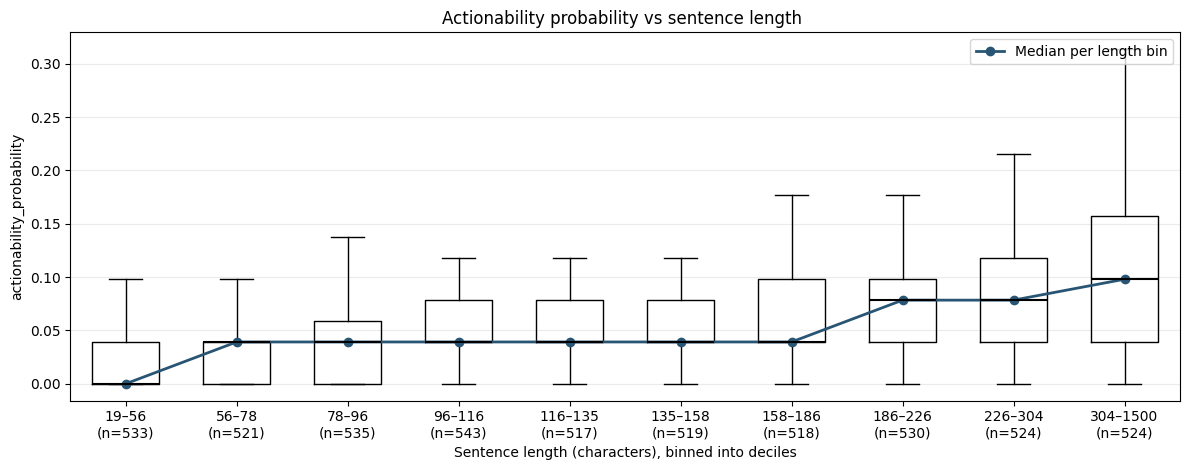

In [77]:
# After-only plot: actionability_probability vs sentence length (binned)


prob_col = "actionability_probability"
text_col = "sentence"

for c in [prob_col, text_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

df_len = df_out[[prob_col, text_col]].copy()
df_len[prob_col] = pd.to_numeric(df_len[prob_col], errors="coerce")
df_len[text_col] = df_len[text_col].astype(str)
df_len["char_len"] = df_len[text_col].str.len()
df_len = df_len.dropna(subset=[prob_col])
df_len = df_len[df_len["char_len"] > 0].copy()

# Create length deciles (10 bins). duplicates='drop' handles tied lengths.
df_len["len_decile"] = pd.qcut(df_len["char_len"], q=10, duplicates="drop")

# Boxplot data in decile order
groups = [g[prob_col].to_numpy() for _, g in df_len.groupby("len_decile", sort=True)]
labels = [f"{int(iv.left)}–{int(iv.right)}" for iv in df_len.groupby("len_decile", sort=True).groups.keys()]

# Summary line: median probability per bin
medians = df_len.groupby("len_decile", sort=True)[prob_col].median().to_numpy()

# counts per bin (for labels)
bin_counts = df_len.groupby("len_decile", sort=True)[prob_col].size().to_numpy()

# Use a data-driven y-limit to make the plot readable (cap at 0.30)
y_hi = float(np.nanpercentile(df_len[prob_col].to_numpy(), 99))
y_hi = min(max(y_hi, 0.15), 0.30)  # keep in a sensible band for reports

fig, ax = plt.subplots(figsize=(12, 4.8))

ax.boxplot(
    groups,
    labels=[f"{lab}\n(n={n})" for lab, n in zip(labels, bin_counts)],
    showfliers=False,
    widths=0.6,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

ax.plot(
    np.arange(1, len(medians) + 1),
    medians,
    color="#295574",
    linewidth=2,
    marker="o",
    label="Median per length bin",
)

ax.set_title("Actionability probability vs sentence length ")
ax.set_xlabel("Sentence length (characters), binned into deciles")
ax.set_ylabel("actionability_probability")


ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

#### add_advice_flag
Testing function add_advice_flag 

In [64]:
# assumes df_out already loaded
text_col = "sentence"
lang_col = "language"
score_col = "actionability_probability"

for c in [text_col, lang_col, score_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

mask_pt = df_out[lang_col].astype(str).str.strip().str.lower().eq("pt")
mask_word = df_out[text_col].astype(str).str.contains(
    r"\b(recomenda|recomendado|recomendação|recomendar|recomendo|recomendava|recomendou|recomende)\b",
    flags=re.IGNORECASE,
    regex=True,
)

hits = df_out.loc[mask_pt & mask_word, [lang_col, score_col, text_col]].copy()
hits[score_col] = pd.to_numeric(hits[score_col], errors="coerce")
hits = hits.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits)} Portuguese sentences containing 'recomend*':\n")
for i, r in hits.iterrows():
    print(f"{i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

# save sentences to a list
portuguese_sentences = hits[text_col].astype(str).tolist()

Found 10 Portuguese sentences containing 'recomend*':

001 | p=0.9804 | CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça-feira (30/4), para auxiliar no resgate dos atingidos pelas enchentes na região de Santa Maria, no Rio Grande do Sul.
002 | p=0.9412 | Em caso de rajadas de vento, o instituto recomenda que as pessoas não se abriguem debaixo de árvores e não estacionem veículos próximos a torres de transmissão e placas de propaganda.
003 | p=0.9412 | O Inmet recomenda que, em caso de rajadas de ventos, as pessoas não se abriguem debaixo de árvores, pois há leve risco de queda e descargas elétricas.
004 | p=0.9412 | A possibilidade de entrada de recur

/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_64382/3786657601.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_word = df_out[text_col].astype(str).str.contains(


In [65]:


# assumes df_out already loaded
text_col = "sentence"
lang_col = "language"
score_col = "actionability_probability"

for c in [text_col, lang_col, score_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# -------------------------
# EN: recommend/suggest/advise (print with score)
# -------------------------
mask_en = df_out[lang_col].astype(str).str.strip().str.lower().eq("en")
mask_en_word = df_out[text_col].astype(str).str.contains(
    r"\b(?:recommend|recommends|recommended|recommending|suggests|advises|urge|urges|urged|urging|advices)\b",
    flags=re.IGNORECASE,
    regex=True,
)

hits_en = df_out.loc[mask_en & mask_en_word, [lang_col, score_col, text_col]].copy()
hits_en[score_col] = pd.to_numeric(hits_en[score_col], errors="coerce")
hits_en = hits_en.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits_en)} English sentences containing recommend*/suggests/advises:\n")
for i, r in hits_en.iterrows():
    print(f"EN {i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

print("\n" + "-" * 80 + "\n")

# -------------------------
# ES: recomend* (print with score)
# -------------------------
mask_es = df_out[lang_col].astype(str).str.strip().str.lower().eq("es")
mask_es_word = df_out[text_col].astype(str).str.contains(
    r"\brecomend",
    flags=re.IGNORECASE,
    regex=True,
)

hits_es = df_out.loc[mask_es & mask_es_word, [lang_col, score_col, text_col]].copy()
hits_es[score_col] = pd.to_numeric(hits_es[score_col], errors="coerce")
hits_es = hits_es.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits_es)} Spanish sentences containing 'recomend*':\n")
for i, r in hits_es.iterrows():
    print(f"ES {i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

Found 5 English sentences containing recommend*/suggests/advises:

EN 001 | p=0.9020 | Higher-than-normal spring runoff has caused over-bank flooding in the Corrales bosque, and village and conservation district officials are urging people not the use the trails in the inundated area.
EN 002 | p=0.8235 | Three other unit leaders who were not with the transport have also been recommended for reprimands.
EN 003 | p=0.8235 | B.C. residents urged not to panic-buy as bare shelves fuel food security angstFlooding has put pressure on B.C.'s dairy, chicken, and egg industry; province says there's enough foodProvincial leaders are urging British Columbians not to hoard food and groceries as disruptions to B.C.'s farm industry and supply chains from historic rain and flooding fuels angst amid consumers.
EN 004 | p=0.8235 | However, for many owners theres no requirement they raise their properties to the heights FEMA recommends.
EN 005 | p=0.8235 | However, for many owners there's no requirement 

In [66]:

import re

text_col = "sentence"
lang_col = "language"

for c in [text_col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# --- English: suggests OR advises ---
mask_en = df_out[lang_col].astype(str).str.strip().str.lower().eq("en")
mask_en_word = df_out[text_col].astype(str).str.contains(r"\b(?:suggests|advises)\b", flags=re.IGNORECASE, regex=True)

hits_en = df_out.loc[mask_en & mask_en_word, [lang_col, text_col]].copy()
print(f"Found {len(hits_en)} English sentences containing 'suggests' or 'advises':\n")
for i, s in enumerate(hits_en[text_col].astype(str).tolist(), start=1):
    print(f"EN {i:03d} | {s}")

print("\n" + "-" * 80 + "\n")

# --- Spanish: sugiere OR aconseja ---
mask_es = df_out[lang_col].astype(str).str.strip().str.lower().eq("es")
mask_es_word = df_out[text_col].astype(str).str.contains(r"\b(?:sugiere|aconseja)\b", flags=re.IGNORECASE, regex=True)

hits_es = df_out.loc[mask_es & mask_es_word, [lang_col, text_col]].copy()
print(f"Found {len(hits_es)} Spanish sentences containing 'sugiere' or 'aconseja':\n")
for i, s in enumerate(hits_es[text_col].astype(str).tolist(), start=1):
    print(f"ES {i:03d} | {s}")

Found 0 English sentences containing 'suggests' or 'advises':


--------------------------------------------------------------------------------

Found 2 Spanish sentences containing 'sugiere' or 'aconseja':

ES 001 | Te has suscrito a notificacionesConfigura y elige tus preferenciasLas alcaldías donde se activó la alerta amarilla son: Álvaro Obregón, Benito Juárez, Coyoacán, Cuauhtémoc, Cuajimalpa, Iztacalco, Iztapalapa, Magdalena Contreras, Tlalpan y Venustiano CarranzaSe sugiere permanecer atento a las actualizaciones meteorológicas.
ES 002 | Recomendaciones para el calorEl Gobierno de la Ciudad de México tiene una serie de recomendaciones para cuidarse ante las altas temperaturas que empezará a experimentar la capital del país, las cuales son:- Usar bloqueador solar- Vestir ropa de colores claros- Utilizar gafas de sol y sombrero o gorra.- También se sugiere evitar comer en la vía pública, ya que los alimentos se descomponen rápidamente.- Beber agua para mantenerse hidratado, aunqu

# Investigation Bias in actionability detection by language 
Distribution of actionability and potential bias in detection by language

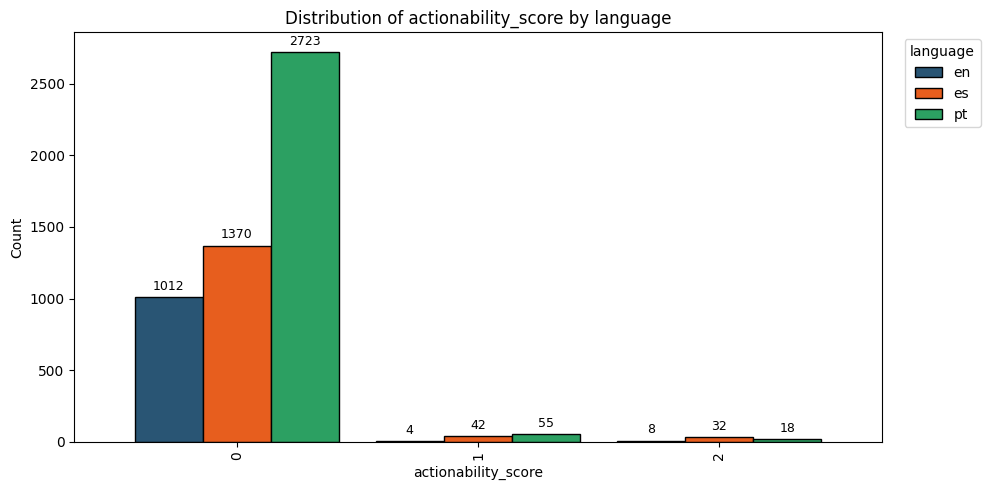

In [67]:

# Distribution of actionability_score (0/1/2) by language, with counts on bars

score_col = "actionability_score"
lang_col = "language"

for c in [score_col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[score_col, lang_col]].copy()
dfp[score_col] = pd.to_numeric(dfp[score_col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[score_col, lang_col])

# Keep only scores 0/1/2
dfp = dfp[dfp[score_col].isin([0, 1, 2])].copy()
dfp[score_col] = dfp[score_col].astype(int)

# counts per score per language (rows=score, cols=language)
ct = (
    dfp.groupby([score_col, lang_col])
       .size()
       .unstack(lang_col)
       .fillna(0)
       .astype(int)
 )

# Ensure rows are ordered 0,1,2 even if missing
ct = ct.reindex([0, 1, 2], fill_value=0)

# Stable column order + colors driven by the first cell
ordered_langs = [l for l in LANG_ORDER if l in ct.columns] + [l for l in ct.columns if l not in LANG_ORDER]
ct = ct[ordered_langs]
colors = [lang_color(l) for l in ct.columns]

ax = ct.plot(kind="bar", figsize=(10, 5), width=0.85, edgecolor="black", color=colors)

ax.set_title("Distribution of actionability_score by language")
ax.set_xlabel("actionability_score")
ax.set_ylabel("Count")
ax.legend(title="language", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v)}" if v > 0 else "" for v in container.datavalues], padding=3, fontsize=9)

plt.show()

In [68]:
#read final cv
df_final = pd.read_csv("../output/enriched.csv")
df_final[["actionability_percentage","country","scope","dominant_frame"]].tail(30)

,actionability_percentage,country,scope,dominant_frame
596,0.00,Mexico,local,response
597,0.00,Mexico,local,impact
598,0.00,Mexico,local,response
599,7.14,Mexico,local,impact
600,0.00,Mexico,local,impact
601,0.00,Mexico,local,response
602,0.00,Mexico,local,impact
603,0.00,Mexico,local,response
604,20.00,Mexico,local,impact
605,25.00,Mexico,local,response


### Investigation false negatives 


In [78]:
df_out[["sentence", "actionability_probability"]].nsmallest(
    20, "actionability_probability"
)

,sentence,actionability_probability
2,El potencial de daños es altísimo.,0.0
7,Incluso algunos puntos pueden experimentar rachas superiores que no se descarta puedan ser de entre 120 y 140 kilómetros por hora en la costa uruguaya.,0.0
12,En los departamentos del sur del Río Negro las precipitaciones serán entre 20 y 50 milímetros en seis horas y las rachas de viento que no superarían los 75 km/h.El nivel naranja de advertencia supone un riesgo meteorológico importante (fenómenos poco habituales y peligrosos para las actividades usuales).,0.0
13,"El amarillo, en tanto, es un llamado de atención.",0.0
14,Riesgo meteorológico solo para actividades concretas.,0.0
18,"Sob direção de Carla Reis e Fabrício Ghomes, no elenco estão 40 atores canelenses e mais de 20 pessoas na parte de produção.",0.0
19,Estátuas Humanas Uma Performance da Paixão de Cristo é igualmente uma reflexão religiosa.,0.0
21,"As apresentações deste final de semana de estreia serão no sábado (12), às 16 horas, e domingo (13), 11 horas, sempre em frente à Catedral de Pedra, com entrada franca.",0.0
22,"FeriadoPara a semana seguinte, marcada pelo feriado de Páscoa, o destaque será a programação religiosa.",0.0
28,The family allowed the newspaper to review the report.,0.0


## Audit by article 

### Investigating Stability in results and relevance of overall actionability per article 

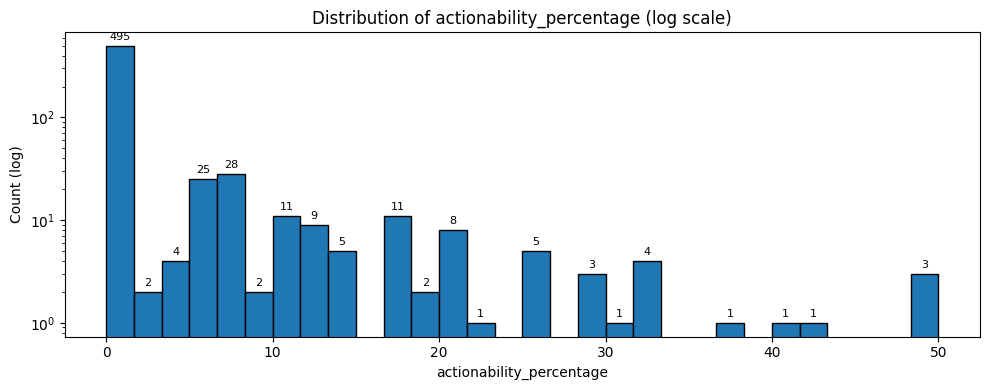

In [70]:
#distrubuiton of actionability percentage 
col = "actionability_percentage"

if col not in df_final.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df_final.columns)}")

s = pd.to_numeric(df_final[col], errors="coerce").dropna()

# If it's 0-1, convert to 0-100 for nicer bins (auto-detect)
if (s.max() <= 1.0) and (s.min() >= 0.0):
    s_plot = s * 100.0
    x_label = "actionability_percentage (%)"
else:
    s_plot = s
    x_label = col

bins = 30  # adjust if needed

fig, ax = plt.subplots(figsize=(10, 4))

counts, bin_edges, patches = ax.hist(s_plot, bins=bins, edgecolor="black")

ax.set_yscale("log")
ax.set_title(f"Distribution of {col} (log scale)")
ax.set_xlabel(x_label)
ax.set_ylabel("Count (log)")

# print counts on top of bars (skip zeros)
for c, p in zip(counts, patches):
    if c <= 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f"{int(c)}",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=8,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()

In [79]:
# Top 10 longest sentences (by character length)

text_col = "sentence"

if text_col not in df_out.columns:
    raise KeyError(f"Column '{text_col}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[text_col] + ([c for c in ["language", "actionability_probability", "actionability_score"] if c in df_out.columns])].copy()
dfp[text_col] = dfp[text_col].fillna("").astype(str)

dfp["char_len"] = dfp[text_col].str.len()
top10_longest = dfp.sort_values("char_len", ascending=False).head(10).reset_index(drop=True)

cols = [c for c in ["language", "actionability_probability", "actionability_score", "char_len", text_col] if c in top10_longest.columns]
display(top10_longest[cols])

# also print them cleanly
for i, r in top10_longest.iterrows():
    lang = r["language"] if "language" in top10_longest.columns else None
    p = r["actionability_probability"] if "actionability_probability" in top10_longest.columns else None
    s = r["actionability_score"] if "actionability_score" in top10_longest.columns else None
    header = f"{i+1:02d} | len={int(r['char_len'])}"
    if lang is not None:
        header += f" | lang={lang}"
    if p is not None:
        header += f" | p={float(p):.4f}" if pd.notna(p) else " | p=nan"
    if s is not None:
        header += f" | score={s}"
    print(header)
    print(r[text_col])

,language,actionability_probability,actionability_score,char_len,sentence
0,pt,0.2745,1,1500,"1 - Processos Geodinâmicos Aplicados a Desastres Naturais1 - Processos Geodinâmicos Aplicados a Desastres Naturais- Modelagem de estabilidade de encostas com dados geotécnicos e topográficos para previsão de áreas suscetíveis a escorregamentos rasos;- Estudos de Limiares de Correlação entre Chuvas e Processos Geodinâmicos, Naturais ou Induzidos, no Território Brasileiro;- Monitoramento de variáveis geotécnicas e climáticas para a implantação de sistema de alerta a movimentos de massa2 - Extremos Meteorológicos e Climatológicos Aplicados a Desastres Naturais2 - Extremos Meteorológicos e Climatológicos Aplicados a Desastres Naturais- Investigação das características dos veranicos na Região Sudeste do Brasil e potencial aplicação para previsões;- Extremos de chuva deflagradores de desastres naturais no Brasil;- Desenvolvimento de potencial aplicação para previsões de veranicos extremos;- Variabilidade subsazonal da precipitação no semiárido;- Desenvolvimento colaborativo de indicadores de risco de colapso de safra3 - Extremos Hidrológicos Aplicados a Desastres Naturais3 - Extremos Hidrológicos Aplicados a Desastres Naturais- Modelagem hidrodinâmica para o desenvolvimento de sistemas de alerta de inundação;- Sistema de previsão hidrológica de longo e curto prazo usando diferentes fontes de dados pluviométricos- Desenvolvimento de sistema de previsão hidrológica para a bacia do Rio São Mateus e bacias da Região Serrana do Estado do Rio de Janeiro- Aplicação de inteligência computa"
1,en,0.1569,0,1500,Jamaica | ReliefWebSkip to main contentLabsBlogMobileAbout UsHelpLogin / RegisterHomeUpdatesCountriesDisastersTopicsOrganizationsJobsTrainingJamaica0 related jobs0 related training programsDisastersHurricane Sandy - Oct 2012Hurricane Tomas - Oct 2010Tropical Storm Nicole - Sep 2010Influenza A (H1N1) Pandemic - Apr 2009Hurricane Paloma - Nov 2008Hurricane Gustav - Aug 2008Hurricane Noel - Oct 2007Hurricane Dean - Aug 2007Jamaica: Floods - Nov 2006Caribbean: Tropical Storm Ernesto - Aug 2006View all disastersMapsJamaicaTropical Storm Nicole (as of 29 Sep 2010) - Location MapView all mapsMost read and sharedMost readMost sharedJamaica builds local awareness about the Paris Climate Conference (COP 21)Impact of main natural disasters on food production in Latin America and the Caribbean (2006-2007)UNDAC Missions in Americas (from 1993 to January 2011)Misiones UNDAC (de 1993 a enero 2011)Impact of Tropical Cyclone Sandy - Overview Map (as of 31 Oct 2012)Jamaica builds local awareness about the Paris Climate Conference (COP 21)Global Estimates 2012 - People displaced by disastersJamaica: Hurricane Sandy - Emergency appeal n° MDRJM003 Final ReportJamaica: Location Map (2013)Unlocking the triple dividend of resilience: why investing in disaster risk management pays offAll UpdatesOnly ReportsMaps / Infographics119 entries foundSort by:Latest|RelevanceWorld+ 15 othersUSAID/OFDA Disaster Risk Reduction (DRR) Programs in Latin America and the CaribbeanUSAID02 Jun 2015World+ 43 othersCount
2,es,0.2549,1,1500,"Honduras | ReliefWebSkip to main contentLabsBlogMobileAbout UsHelpLogin / RegisterHomeUpdatesCountriesDisastersTopicsOrganizationsJobsTrainingHonduras8 related jobs0 related training programsDisastersLatin America: Storm Surge - May 2015Central America: Drought - Mar 2014Central America: Dengue Outbreak - 2013-2014Honduras: Floods and Landslides - May 2012Tropical Depression 12-E - Oct 2011Honduras: Storm Surge - Sep 2011Tropical Storm Harvey - Aug 2011Honduras: Floods - Jan 2011Hurricane Paula - Oct 2010Tropical Storm Matthew - Sep 2010View all disastersMapsHondurasHonduras, municipios afectados por sequía (al 24 de agosto 2015)View all mapsMost read and sharedMost readMost sharedGlobal Emergency Overview Snapshot 11 August 25 August 2015Dengue y chikungunya amenazan con desatar epidemia en CentroaméricaGlobal Weather Hazards Summary August 28 - Septe

01 | len=1500 | lang=pt | p=0.2745 | score=1
1 - Processos Geodinâmicos Aplicados a Desastres Naturais1 - Processos Geodinâmicos Aplicados a Desastres Naturais- Modelagem de estabilidade de encostas com dados geotécnicos e topográficos para previsão de áreas suscetíveis a escorregamentos rasos;- Estudos de Limiares de Correlação entre Chuvas e Processos Geodinâmicos, Naturais ou Induzidos, no Território Brasileiro;- Monitoramento de variáveis geotécnicas e climáticas para a implantação de sistema de alerta a movimentos de massa2 - Extremos Meteorológicos e Climatológicos Aplicados a Desastres Naturais2 - Extremos Meteorológicos e Climatológicos Aplicados a Desastres Naturais- Investigação das características dos veranicos na Região Sudeste do Brasil e potencial aplicação para previsões;- Extremos de chuva deflagradores de desastres naturais no Brasil;- Desenvolvimento de potencial aplicação para previsões de veranicos extremos;- Variabilidade subsazonal da precipitação no semiárido;- D

In [71]:
!python -m spacy download pt_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/42.4 MB ? eta -:--:--  Downloading https://github.com/explosion/spacy-models/releases/download/pt_core_news_md-3.8.0/pt_core_news_md-3.8.0-py3-none-any.whl (42.4 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 27.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 27.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')


In [72]:
import spacy

# Load the medium Portuguese model
nlp = spacy.load("pt_core_news_md")

text = "Evite atividades físicas ao ar livre e exposição ao sol das 10h às 17h."
doc = nlp(text)

for token in doc:
    if token.pos_ == "VERB":
        print(f"Verb: {token.text}")
        print(f"  Lemma: {token.lemma_}")
        print(f"  Morphology: {token.morph}")
        print(f"  Mood: {token.morph.get('Mood')}")
        print(f"  Person: {token.morph.get('Person')}")
        print(f"  Tense: {token.morph.get('Tense')}\n")

Verb: Evite
  Lemma: evite
  Morphology: Mood=Sub|Number=Sing|Tense=Pres|VerbForm=Fin
  Mood: ['Sub']
  Person: []
  Tense: ['Pres']



In [73]:
for t in doc:
    print(
        f"{t.i:02d} {t.text:<8} "
        f"pos={t.pos_:<6} tag={t.tag_:<10} dep={t.dep_:<8} head={t.head.text:<8} morph={t.morph}"
    )

root = next((t for t in doc if t.dep_ == "ROOT"), None)
print("\nROOT:", root.text if root else None, "| pos:", root.pos_ if root else None)

00 Evite    pos=VERB   tag=VERB       dep=ROOT     head=Evite    morph=Mood=Sub|Number=Sing|Tense=Pres|VerbForm=Fin
01 atividades pos=NOUN   tag=NOUN       dep=obj      head=Evite    morph=Gender=Fem|Number=Plur
02 físicas  pos=ADJ    tag=ADJ        dep=amod     head=atividades morph=Gender=Fem|Number=Plur
03 ao       pos=ADP    tag=ADP        dep=case     head=ar       morph=Definite=Def|Gender=Masc|Number=Sing|PronType=Art
04 ar       pos=NOUN   tag=NOUN       dep=nmod     head=atividades morph=Gender=Masc|Number=Sing
05 livre    pos=ADJ    tag=ADJ        dep=amod     head=ar       morph=Gender=Masc|Number=Sing
06 e        pos=CCONJ  tag=CCONJ      dep=cc       head=exposição morph=
07 exposição pos=NOUN   tag=NOUN       dep=conj     head=livre    morph=Gender=Fem|Number=Sing
08 ao       pos=ADP    tag=ADP        dep=case     head=sol      morph=Definite=Def|Gender=Masc|Number=Sing|PronType=Art
09 sol      pos=NOUN   tag=NOUN       dep=nmod     head=exposição morph=Gender=Masc|Number

In [74]:
import pandas as pd

score_col = "actionability_score"
text_col = "sentence"

for c in [score_col, text_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[score_col, text_col, "language"]].copy() if "language" in df_out.columns else df_out[[score_col, text_col]].copy()
dfp[score_col] = pd.to_numeric(dfp[score_col], errors="coerce")
dfp[text_col] = dfp[text_col].fillna("").astype(str)

hits = dfp.loc[dfp[score_col].eq(1)].reset_index(drop=True)

print(f"Found {len(hits)} sentences with {score_col} == 1\n")

for i, r in hits.iterrows():
    if "language" in hits.columns:
        print(f"{i+1:04d} | lang={r['language']} | score=1")
    else:
        print(f"{i+1:04d} | score=1")
    print(r[text_col])
    print()

Found 101 sentences with actionability_score == 1

0001 | lang=pt | score=1
Grande perigo: cidades do ES recebem alerta vermelho para chuvasO Espírito Santo recebeu alerta vermelho para acumulado de chuva, válido durante todo o sábado (5).

0002 | lang=pt | score=1
Em caso de perigo, a Defesa Civil orienta que a população adote medidas de proteção, evite se arriscar em áreas alagadas e busque refúg

0003 | lang=pt | score=1
O alerta também é válido para o Distrito Federal e cidades de outros quatro estados (Goiás, Mato Grosso do Sul, Mato Grosso e São Paulo).Confira a lista de cidades em alerta vermelho para baixa umidade em Minas GeraisAbadia dos DouradosAbaetéÁgua CompridaAguanilAlfenasAlpinópolisAlterosaAlvorada de MinasAraçaíAraguariAraporãArapuáAraújosAraxáArceburgoArcosAreadoAugusto de LimaBaldimBambuíBarão de CocaisBelo HorizonteBelo ValeBetimBiquinhasBoa EsperançaBocaiúvaBom DespachoBom Jesus da PenhaBom Jesus do AmparoBonfimBonfinópolis de MinasBrasilândia de MinasBrumadinhoBu

In [75]:


target = "The safety of children at schools."

# --- find candidate text column ---
text_col_candidates = ["sentence", "text", "clean_text", "original_sentence"]
text_col = next((c for c in text_col_candidates if c in df_out.columns), None)
if text_col is None:
    raise KeyError(f"No text column found. Tried {text_col_candidates}. Available: {list(df_out.columns)}")

# --- filter exact matches (trim to avoid whitespace mismatches) ---
mask = df_out[text_col].fillna("").astype(str).str.strip().eq(target.strip())
hits = df_out.loc[mask].copy()

print(f"Matches found: {len(hits)} (text column: '{text_col}')")
if len(hits) == 0:
    # optional: try a contains search to help you find near-matches
    near = df_out.loc[
        df_out[text_col].fillna("").astype(str).str.contains("safety of children", case=False, regex=False),
        [c for c in ["language", "actionability_probability", "actionability_score", text_col] if c in df_out.columns]
    ].head(20)
    print("\nNo exact match. Near matches (first 20):")
    display(near)
else:
    # show everything for the hit(s)
    with pd.option_context("display.max_columns", None, "display.max_colwidth", None, "display.width", 0):
        display(hits)

    # also print as key-value pairs (useful for the appendix)
    for i, row in hits.reset_index(drop=False).iterrows():
        print("\n" + "-" * 80)
        print(f"Row {i+1} | original_index={row['index'] if 'index' in row else 'n/a'}")
        for col in hits.columns:
            val = row[col]
            print(f"{col}: {val}")

Matches found: 1 (text column: 'sentence')


,article_id,flood_id,language,country,sentence,sentence_num,adjective,adposition,adverb,auxiliary,coordinating conjunction,determiner,interjection,noun,numeral,particle,pronoun,proper noun,punctuation,subordinating conjunction,symbol,verb,other,verbs_imperative,verbs_subjunctive,auxiliary_modals,imperative_count,short_term_count,long_term_count,spatial_count,subjunctive_count,has_agent,has_action,has_location,srl_complete,advice,actionability_probability,actionability_score
2916,375,255,en,United States of America,The safety of children at schools.,0,[],"['of', 'at']",[],[],[],['The'],[],"['safety', 'children', 'schools']",[],[],[],[],['.'],[],[],[],[],[],[],[],0,0,0,0,0.0,0,0,1,0,0,0.0,0



--------------------------------------------------------------------------------
Row 1 | original_index=2916
article_id: 375
flood_id: 255
language: en
country: United States of America
sentence: The safety of children at schools.
sentence_num: 0
adjective: []
adposition: ['of', 'at']
adverb: []
auxiliary: []
coordinating conjunction: []
determiner: ['The']
interjection: []
noun: ['safety', 'children', 'schools']
numeral: []
particle: []
pronoun: []
proper noun: []
punctuation: ['.']
subordinating conjunction: []
symbol: []
verb: []
other: []
verbs_imperative: []
verbs_subjunctive: []
auxiliary_modals: []
imperative_count: 0
short_term_count: 0
long_term_count: 0
spatial_count: 0
subjunctive_count: 0.0
has_agent: 0
has_action: 0
has_location: 1
srl_complete: 0
advice: 0
actionability_probability: 0.0
actionability_score: 0


In [76]:
import pandas as pd

target = "The safety of children at schools."

# --- find candidate text column ---
text_col_candidates = ["sentence", "text", "clean_text", "original_sentence"]
text_col = next((c for c in text_col_candidates if c in df_out.columns), None)
if text_col is None:
    raise KeyError(f"No text column found. Tried {text_col_candidates}. Available: {list(df_out.columns)}")

# --- filter exact matches (trim to avoid whitespace mismatches) ---
mask = df_out[text_col].fillna("").astype(str).str.strip().eq(target.strip())
hits = df_out.loc[mask].copy()

print(f"Matches found: {len(hits)} (text column: '{text_col}')")
if len(hits) == 0:
    # optional: try a contains search to help you find near-matches
    near = df_out.loc[
        df_out[text_col].fillna("").astype(str).str.contains("safety of children", case=False, regex=False),
        [c for c in ["language", "actionability_probability", "actionability_score", text_col] if c in df_out.columns]
    ].head(20)
    print("\nNo exact match. Near matches (first 20):")
    display(near)
else:
    # show everything for the hit(s)
    with pd.option_context("display.max_columns", None, "display.max_colwidth", None, "display.width", 0):
        display(hits)

    # also print as key-value pairs (useful for the appendix)
    for i, row in hits.reset_index(drop=False).iterrows():
        print("\n" + "-" * 80)
        print(f"Row {i+1} | original_index={row['index'] if 'index' in row else 'n/a'}")
        for col in hits.columns:
            val = row[col]
            print(f"{col}: {val}")

Matches found: 1 (text column: 'sentence')


,article_id,flood_id,language,country,sentence,sentence_num,adjective,adposition,adverb,auxiliary,coordinating conjunction,determiner,interjection,noun,numeral,particle,pronoun,proper noun,punctuation,subordinating conjunction,symbol,verb,other,verbs_imperative,verbs_subjunctive,auxiliary_modals,imperative_count,short_term_count,long_term_count,spatial_count,subjunctive_count,has_agent,has_action,has_location,srl_complete,advice,actionability_probability,actionability_score
2916,375,255,en,United States of America,The safety of children at schools.,0,[],"['of', 'at']",[],[],[],['The'],[],"['safety', 'children', 'schools']",[],[],[],[],['.'],[],[],[],[],[],[],[],0,0,0,0,0.0,0,0,1,0,0,0.0,0



--------------------------------------------------------------------------------
Row 1 | original_index=2916
article_id: 375
flood_id: 255
language: en
country: United States of America
sentence: The safety of children at schools.
sentence_num: 0
adjective: []
adposition: ['of', 'at']
adverb: []
auxiliary: []
coordinating conjunction: []
determiner: ['The']
interjection: []
noun: ['safety', 'children', 'schools']
numeral: []
particle: []
pronoun: []
proper noun: []
punctuation: ['.']
subordinating conjunction: []
symbol: []
verb: []
other: []
verbs_imperative: []
verbs_subjunctive: []
auxiliary_modals: []
imperative_count: 0
short_term_count: 0
long_term_count: 0
spatial_count: 0
subjunctive_count: 0.0
has_agent: 0
has_action: 0
has_location: 1
srl_complete: 0
advice: 0
actionability_probability: 0.0
actionability_score: 0
